In [5]:
# --- Step 1. Imports ---
import pandas as pd
import matplotlib.pyplot as plt

# Constants
DATE_COL = "timestamp"
TARGET = "logistics_delay"
CAT_COLS = ["shipment_status","logistics_delay_reason"]
NUM_COLS = ["inventory_level","temperature","humidity",
            "waiting_time","user_transaction_amount",
            "user_purchase_frequency","asset_utilization","demand_forecast"]

# --- Step 2. Load Data ---
df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")
print("✅ Data loaded:", df.shape)
df.head()


✅ Data loaded: (1000, 19)


,timestamp,asset_id,latitude,longitude,inventory_level,shipment_status,temperature,humidity,traffic_status,waiting_time,user_transaction_amount,user_purchase_frequency,logistics_delay_reason,asset_utilization,demand_forecast,logistics_delay,month,dow,hour
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1,3,2,0
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,in transit,22.5,54.3,Heavy,16,439,7,weather,80.9,174,1,10,2,7
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,in transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0,7,0,18
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,delivered,25.4,52.3,Heavy,37,227,5,traffic,97.4,160,1,10,0,0
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1,9,4,15


In [8]:
# --- Step 3. Feature Engineering Functions ---

def make_features(df):
    # Ensure datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    # Weekend delivery
    df["is_weekend_delivery"] = df["dow"].isin([5,6]).astype(int)
    
    # Peak season (Nov-Dec)
    df["is_peak_season"] = df["month"].isin([11,12]).astype(int)
    
    # Rolling delay rate per asset_id (FIXED with transform instead of apply)
    df = df.sort_values(["asset_id","timestamp"])
    df["asset_delay_rate_30d"] = (
        df.groupby("asset_id")[TARGET]
          .transform(lambda x: x.shift().rolling(30, min_periods=1).mean())
    )
    
    # One-hot encoding categorical variables
    df = pd.get_dummies(
        df,
        columns=CAT_COLS,
        drop_first=True
    )
    
    return df


def time_based_split(df, date_col=DATE_COL, cutoff=None):
    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Sort by time
    df = df.sort_values(date_col)
    
    # Default cutoff at 80% quantile
    if cutoff is None:
        cutoff = df[date_col].quantile(0.8)
    
    # Train-test split
    train = df[df[date_col] <= cutoff].copy()
    test  = df[df[date_col] >  cutoff].copy()
    
    return train, test, cutoff


In [9]:
# --- Step 4. Apply Feature Engineering ---
df_fe = make_features(df)
print("✅ Features engineered. New shape:", df_fe.shape)
df_fe.head()


✅ Features engineered. New shape: (1000, 24)


,timestamp,asset_id,latitude,longitude,inventory_level,temperature,humidity,traffic_status,waiting_time,user_transaction_amount,...,month,dow,hour,is_weekend_delivery,is_peak_season,asset_delay_rate_30d,shipment_status_delivered,shipment_status_in transit,logistics_delay_reason_traffic,logistics_delay_reason_weather
610,2024-01-10 16:52:14,Truck_1,49.3049,-55.6493,199,23.4,64.4,Heavy,59,476,...,1,2,16,0,0,NaN,True,False,True,False
439,2024-01-10 20:02:28,Truck_1,47.5481,-97.4831,465,24.0,72.4,Heavy,48,112,...,1,2,20,0,0,1.0,False,False,False,False
788,2024-01-13 15:51:27,Truck_1,23.2259,110.6901,147,18.7,68.5,Heavy,25,439,...,1,5,15,1,0,1.0,False,True,False,False
765,2024-01-13 21:07:39,Truck_1,-12.4175,135.9866,339,26.4,73.8,Clear,58,488,...,1,5,21,1,0,1.0,False,False,False,False
77,2024-01-15 12:01:25,Truck_1,-20.0696,-73.2689,486,29.1,78.4,Clear,21,158,...,1,0,12,0,0,1.0,True,False,False,False


In [11]:
# --- Step 5. Time-Based Train/Test Split ---
train, test, cutoff = time_based_split(df_fe)

print("✅ Split complete.")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Cutoff date:", cutoff)

# Save processed datasets
train.to_csv("../data/interim/train.csv", index=False)
test.to_csv("../data/interim/test.csv", index=False)


✅ Split complete.
Train shape: (800, 24)
Test shape : (200, 24)
Cutoff date: 2024-10-22 11:28:44.600000


Train delay rate: 0.5725
Test delay rate : 0.54


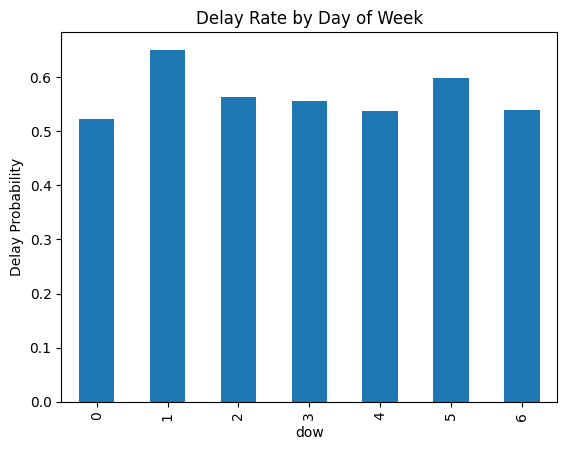

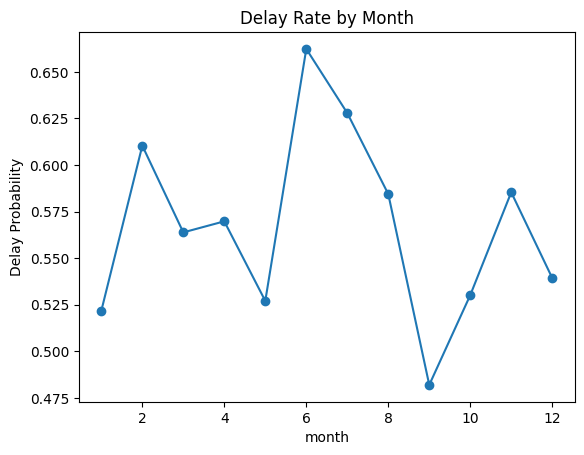

In [12]:
# --- Step 6. Exploratory Checks ---

# Check class balance after split
print("Train delay rate:", train[TARGET].mean())
print("Test delay rate :", test[TARGET].mean())

# Plot: Delays by weekend vs weekday
delay_by_weekend = df.groupby("dow")[TARGET].mean()
delay_by_weekend.plot(kind="bar", title="Delay Rate by Day of Week")
plt.ylabel("Delay Probability")
plt.show()

# Plot: Delays by month
delay_by_month = df.groupby("month")[TARGET].mean()
delay_by_month.plot(kind="line", marker="o", title="Delay Rate by Month")
plt.ylabel("Delay Probability")
plt.show()
